In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
torch.manual_seed(42)
np.random.seed(42)

In [23]:
def f0(x, y):
    """f0(x,y) = x^2 + y^2"""
    return x**2 + y**2

def f1(x, y):
    """Ackley function"""
    return (
        -20 * torch.exp(-0.2 * torch.sqrt(0.5 * (x**2 + y**2)))
        - torch.exp(0.5 * (torch.cos(2 * np.pi * x) + torch.cos(2 * np.pi * y)))
        + np.e
        + 20
    )

def f2(x, y):
    """Himmelblau function"""
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# Versión numéricamente estable de f1 para optimización con autograd
def f1_opt(x, y):
    return (
        -20 * torch.exp(-0.2 * torch.sqrt(0.5 * (x**2 + y**2) + 1e-12))
        - torch.exp(0.5 * (torch.cos(2 * np.pi * x) + torch.cos(2 * np.pi * y)))
        + np.e
        + 20
    )

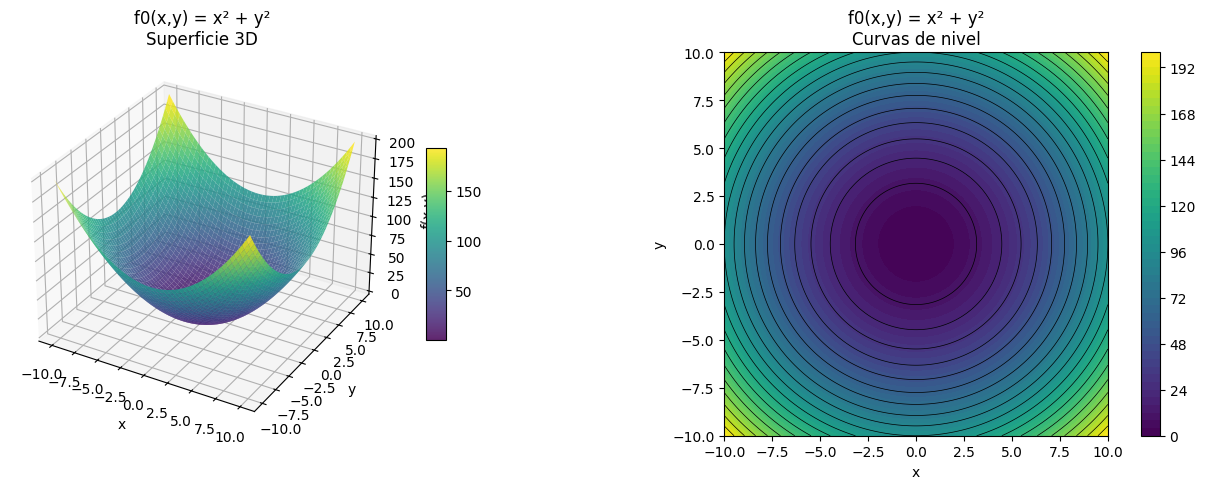

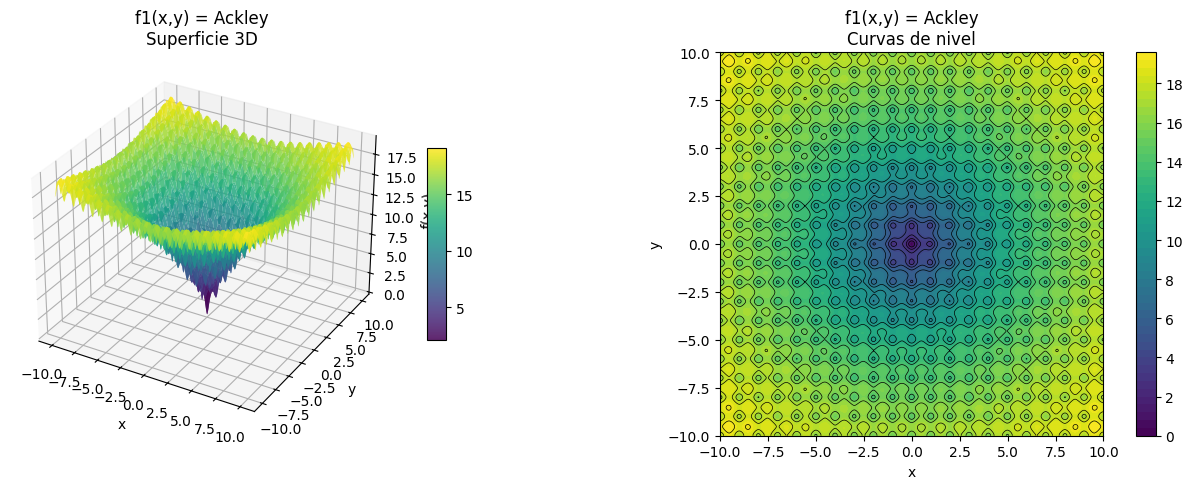

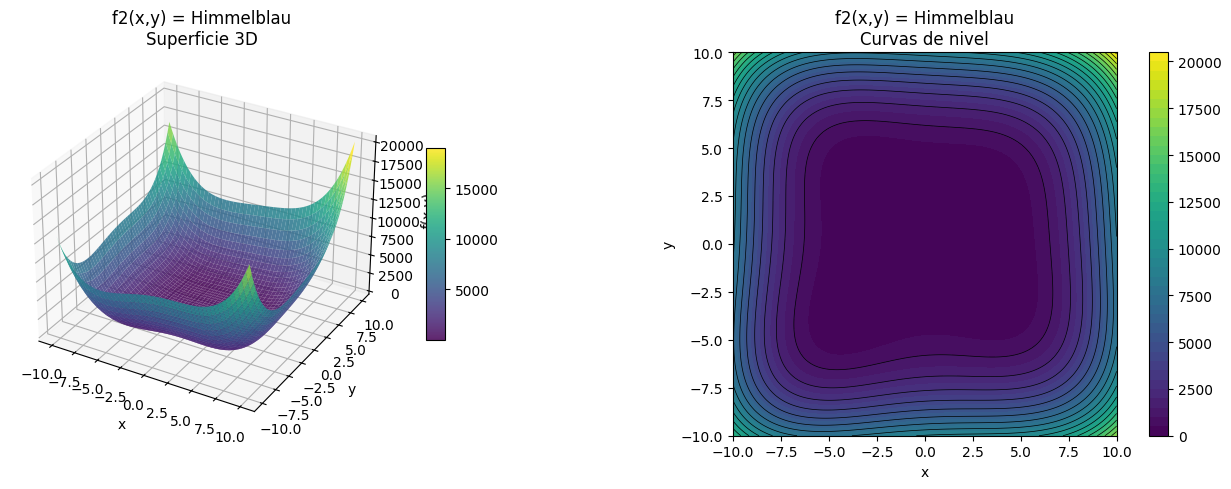

In [24]:
x = torch.linspace(-10, 10, 400)
y = torch.linspace(-10, 10, 400)
X, Y = torch.meshgrid(x, y, indexing='ij')

funciones = [
    ("f0(x,y) = x² + y²", f0),
    ("f1(x,y) = Ackley", f1),
    ("f2(x,y) = Himmelblau", f2),
]

for nombre, f in funciones:
    Z = f(X, Y)

    fig = plt.figure(figsize=(14, 5))

    # Superficie 3D
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf = ax1.plot_surface(
        X.numpy(), Y.numpy(), Z.numpy(),
        cmap='viridis', alpha=0.85, linewidth=0, antialiased=True
    )
    ax1.set_title(f"{nombre}\nSuperficie 3D")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("f(x,y)")
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

    # Curvas de nivel
    ax2 = fig.add_subplot(1, 2, 2)
    cont = ax2.contourf(X.numpy(), Y.numpy(), Z.numpy(), levels=50, cmap='viridis')
    ax2.contour(X.numpy(), Y.numpy(), Z.numpy(), levels=20, colors='k', linewidths=0.5)
    ax2.set_title(f"{nombre}\nCurvas de nivel")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_aspect('equal')
    fig.colorbar(cont, ax=ax2)

    plt.tight_layout()
    plt.show()

In [25]:
def optimize_adam(f, x0, y0, steps=5000, lr=0.01):
    """Minimiza f usando Adam desde el punto inicial (x0, y0)."""
    x = torch.tensor([x0], dtype=torch.float32, device=device, requires_grad=True)
    y = torch.tensor([y0], dtype=torch.float32, device=device, requires_grad=True)

    optimizer = torch.optim.Adam([x, y], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        loss = f(x, y)
        loss.backward()
        optimizer.step()

    return x.item(), y.item(), loss.item()


def find_unique_minima(f, starts, steps=5000, lr=0.01, tol=1e-2):
    """Ejecuta optimización desde varios inicios y devuelve mínimos únicos."""
    results = []
    for x0, y0 in starts:
        res = optimize_adam(f, x0, y0, steps=steps, lr=lr)
        # Evitar duplicados cercanos
        if not any(np.allclose(res[:2], r[:2], atol=tol) for r in results):
            results.append(res)
    return results

In [26]:
starts_f0 = [(5, 5), (-5, 5), (5, -5), (-5, -5), (0, 0)]
min_f0 = find_unique_minima(f0, starts_f0, steps=3000, lr=0.01)

print("Mínimos encontrados para f0:")
for m in min_f0:
    print(f"  x = {m[0]:.6f}, y = {m[1]:.6f}, f = {m[2]:.10f}")

Mínimos encontrados para f0:
  x = 0.000000, y = 0.000000, f = 0.0000000000


In [ ]:
starts_f1 = [
    (0.1, 0.1), (-0.1, 0.1), (0.1, -0.1), (-0.1, -0.1),
    (1, 1), (-1, 1), (1, -1), (-1, -1),
    (5, 5), (-5, 5), (5, -5), (-5, -5),
    (8, 8), (-8, -8), (0, 5), (5, 0), (-5, 0), (0, -5)
]

min_f1 = find_unique_minima(f1_opt, starts_f1, steps=5000, lr=0.005, tol=1e-2)

# Ordena por valor de función
min_f1_sorted = sorted(min_f1, key=lambda r: r[2])

print("Mínimos encontrados para f1 (pueden ser locales):")
for m in min_f1_sorted[:10]:
    print(f"  x = {m[0]:.6f}, y = {m[1]:.6f}, f = {m[2]:.10f}")

best_f1 = min_f1_sorted[0]
print("\nMejor mínimo encontrado para f1:")
print(f"  x = {best_f1[0]:.6f}, y = {best_f1[1]:.6f}, f = {best_f1[2]:.10f}")

# Verificación del mínimo global teórico (0,0)
x0 = torch.tensor([0.0], dtype=torch.float32)
y0 = torch.tensor([0.0], dtype=torch.float32)
print(f"\nVerificación en (0,0): f1(0,0) = {f1(x0, y0).item():.10f}")

In [ ]:
starts_f2 = [
    (3, 2), (-3, 3), (-3, -3), (3, -2),
    (0, 0), (5, 5), (-5, 5), (5, -5), (-5, -5),
    (0, 5), (5, 0), (-5, 0), (0, -5)
]

min_f2 = find_unique_minima(f2, starts_f2, steps=5000, lr=0.01, tol=1e-2)

print("Mínimos encontrados para f2:")
for m in min_f2:
    print(f"  x = {m[0]:.6f}, y = {m[1]:.6f}, f = {m[2]:.10f}")

# Verificación de los 4 mínimos globales conocidos
minimos_conocidos = [
    (3.0, 2.0),
    (-2.805118, 3.131312),
    (-3.779310, -3.283186),
    (3.584428, -1.848126)
]

print("\nVerificación de mínimos conocidos de Himmelblau:")
for xv, yv in minimos_conocidos:
    x_t = torch.tensor([xv], dtype=torch.float32)
    y_t = torch.tensor([yv], dtype=torch.float32)
    print(f"  f2({xv:.6f}, {yv:.6f}) = {f2(x_t, y_t).item():.10f}")